# MAE, residual distribution and predictive uncertainty

This notebook evaluates the saved CatBoost predictive models for each case study by
measuring the **mean absolute error (MAE)**, visualising the **residual
distribution** (`y_true - y_pred`), and, for the regression model, inspecting the
**predictive uncertainty** it produces.

Three scenarios:

1. **Base case** &ndash; the regression model on the normalised remaining time
   (`sigmoid_mm`): point accuracy (MAE, residuals) **and** its predictive standard
   deviation, since the model now returns both.
2. **Comparison with DIEM** &ndash; combined utility as a weighted sum of completion
   outcome and remaining time (&lambda; = 0.5), compared against the MAE values
   reported by DIEM.
3. **Non-normalised time** &ndash; the same regression model, with predictions and
   ground truth reported in minutes after inverting the normalisation.

All the repeated logic (loading data and models, aligning features, computing the MAE,
plotting) is collected in the helper functions of the setup cell.

> Note: the time model no longer applies a `log1p` transform to the target (an ablation
> showed it did not help), but `model.predict()` still returns the mean in `sigmoid_mm`
> space, so the point-accuracy scenarios are computed exactly as before.

## Setup: imports, configuration and helper functions

The cell below defines:

- the project paths and the dataset configuration (`DATASETS`, `DIEM_MAE`);
- the feature preprocessing functions (`align_and_coerce`,
  `coerce_categorical_features_for_model`);
- cached loading of the test data and models (`load_test_context`, `load_model`,
  `predict_values`, `predict_positive_proba`, `predict_uncertainty`);
- the de-normalisation of the remaining time (`fit_original_scalers`,
  `inverse_normalize_to_minutes`);
- the result computation and reusable plots (`make_result`, `mae_table`,
  `uncertainty_table`, `plot_residual_distributions`, `plot_mae_comparison`).

In [19]:
import sys
from pathlib import Path
from types import SimpleNamespace

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ---------------------------------------------------------------------
# Project paths
# ---------------------------------------------------------------------
base_dir = Path.cwd()
if not (base_dir / "case_studies").exists():
    base_dir = Path("C:/Users/Utente/Desktop/tesi magistrale/Code/multi_obj").resolve()
sys.path.insert(0, str(base_dir))

from utils.get_features import get_features
from utils.predictive_models_functions import prepare_df_for_ml

# ---------------------------------------------------------------------
# Dataset / case study configuration
# ---------------------------------------------------------------------
DATASETS = {
    "BAC":             {"folder": "BAC",          "case_study": "BAC"},
    "BPIC2017_Before": {"folder": "bpi17_before", "case_study": "bpi17_before"},
    "BPIC2017_After":  {"folder": "bpi17_after",  "case_study": "bpi17_after"},
    "BPIC2012":        {"folder": "BPI12",        "case_study": "BPI12"},
}

END_DATE_NAME = "time:timestamp"
START_DATE_NAME = "start:timestamp"

# MAE values reported by DIEM: comparison baseline for the combined utility.
DIEM_MAE = {
    "BAC": 0.10,
    "BPIC2017_Before": 0.26,
    "BPIC2017_After": 0.26,
    "BPIC2012": 0.25,
}


def dataset_file(dataset_key, *parts):
    """Absolute path of a file inside the case_studies folder of the dataset."""
    return base_dir / "case_studies" / DATASETS[dataset_key]["folder"] / Path(*parts)


# ---------------------------------------------------------------------
# Feature preprocessing for the saved models
# ---------------------------------------------------------------------
def coerce_categorical_features_for_model(X, model, categorical_columns):
    """Coerce categorical columns to the dtype expected by the model's OneHotEncoder."""
    try:
        transformation_step = model.named_steps["transformation"]
    except Exception:
        return X
    if not hasattr(transformation_step, "named_transformers_"):
        return X
    cat_transformer = transformation_step.named_transformers_.get("cat")
    if cat_transformer is None:
        return X
    onehot = cat_transformer.named_steps.get("onehot") if hasattr(cat_transformer, "named_steps") else None
    if onehot is None or not hasattr(onehot, "categories_"):
        return X

    for idx, col_name in enumerate(categorical_columns):
        if col_name not in X.columns:
            continue
        known = onehot.categories_[idx] if idx < len(onehot.categories_) else None
        if known is None or len(known) == 0:
            continue
        sample = X[col_name]
        first = next((v for v in known if pd.notna(v)), None)
        if first is None:
            continue
        try:
            if isinstance(first, (str, np.str_)):
                X[col_name] = sample.fillna("").astype(str)
            elif isinstance(first, (int, np.integer)):
                X[col_name] = pd.to_numeric(sample, errors="coerce").astype("Int64")
            elif isinstance(first, (float, np.floating, bool, np.bool_)):
                X[col_name] = pd.to_numeric(sample, errors="coerce")
            else:
                X[col_name] = sample.fillna("").astype(str)
        except Exception:
            X[col_name] = sample.fillna("").astype(str)
    return X


def align_and_coerce(X, model, categorical_features):
    """Reorder columns according to `feature_names_in_` and coerce the categoricals."""
    if hasattr(model, "feature_names_in_"):
        expected = list(model.feature_names_in_)
        if list(X.columns) != expected:
            X = X.reindex(columns=expected)
    return coerce_categorical_features_for_model(
        X, model, [c for c in categorical_features if c in X.columns]
    )


# ---------------------------------------------------------------------
# Loading test data and models (with cache)
# ---------------------------------------------------------------------
_CONTEXT_CACHE = {}


def load_test_context(dataset_key):
    """Load test_data.csv and extract X_test, y_label, y_sigmoid. Result is cached."""
    if dataset_key in _CONTEXT_CACHE:
        return _CONTEXT_CACHE[dataset_key]

    case_study = DATASETS[dataset_key]["case_study"]
    case_id_name, _, _, _, categorical_features, columns_to_remove = get_features(case_study)
    test_df = pd.read_csv(
        dataset_file(dataset_key, "test_data.csv"),
        parse_dates=[END_DATE_NAME, START_DATE_NAME],
    )
    X_test, y_label, y_sigmoid = prepare_df_for_ml(
        test_df, case_id_name=case_id_name, columns_to_remove=columns_to_remove
    )
    ctx = SimpleNamespace(
        dataset_key=dataset_key,
        case_study=case_study,
        case_id_name=case_id_name,
        categorical_features=categorical_features,
        test_df=test_df,
        X_test=X_test,
        y_label=np.asarray(y_label, dtype=float),
        y_sigmoid=np.asarray(y_sigmoid, dtype=float),
    )
    _CONTEXT_CACHE[dataset_key] = ctx
    return ctx


def load_model(dataset_key, filename):
    """Load a .joblib model from the dataset's `model/` subfolder."""
    return joblib.load(dataset_file(dataset_key, "model", filename))


def predict_values(model, ctx):
    """Point prediction of a regressor, with features aligned to the model.

    The time model's pipeline ends in an `UncertaintyRegressor` whose `.predict`
    already returns just the mean (the `sigmoid_mm` prediction), so this keeps
    working unchanged after the switch to `RMSEWithUncertainty`.
    """
    X = align_and_coerce(ctx.X_test.copy(), model, ctx.categorical_features)
    return np.asarray(model.predict(X), dtype=float)


def predict_positive_proba(model, ctx):
    """Positive-class probability of a classifier; falls back to predict()."""
    X = align_and_coerce(ctx.X_test.copy(), model, ctx.categorical_features)
    if hasattr(model, "predict_proba"):
        return np.asarray(model.predict_proba(X)[:, 1], dtype=float)
    return np.asarray(model.predict(X), dtype=float)


def predict_uncertainty(model, ctx):
    """Run the time model through its pipeline and return {mean, std} produced by
    `UncertaintyRegressor` -- the point prediction and its recalibrated
    (aleatoric) predictive standard deviation. If the loaded model has no
    uncertainty support (an older MAE/RMSE model), std is all zeros.
    """
    X = align_and_coerce(ctx.X_test.copy(), model, ctx.categorical_features)
    steps = getattr(model, "named_steps", {})
    pred_step = steps.get("prediction", model)
    Xt = steps["transformation"].transform(X) if "transformation" in steps else X
    if hasattr(pred_step, "predict_uncertainty"):
        out = pred_step.predict_uncertainty(Xt)
        return {"mean": np.asarray(out["mean"], dtype=float), "std": np.asarray(out["std"], dtype=float)}
    mean = np.asarray(model.predict(X), dtype=float)
    return {"mean": mean, "std": np.zeros_like(mean)}


# ---------------------------------------------------------------------
# Remaining-time de-normalisation (real-minutes case)
# ---------------------------------------------------------------------
def fit_original_scalers(train_df):
    """Rebuild the StandardScaler + MinMaxScaler used to create `sigmoid_mm`."""
    train = train_df.copy()
    scaler = StandardScaler()
    standard = scaler.fit_transform(train[["remaining_time"]])
    sigmoid = 1.0 / (1.0 + np.exp(-standard))
    mm_scaler = MinMaxScaler().fit(sigmoid)
    return scaler, mm_scaler


def inverse_normalize_to_minutes(normalized_values, scaler, mm_scaler):
    """Invert sigmoid_mm -> real seconds -> minutes."""
    vals = np.clip(np.asarray(normalized_values, dtype=float).reshape(-1, 1), 1e-7, 1 - 1e-7)
    sig = np.clip(mm_scaler.inverse_transform(vals), 1e-7, 1 - 1e-7)
    standard = np.log(sig / (1.0 - sig))
    seconds = scaler.inverse_transform(standard).flatten()
    return seconds / 60.0


# ---------------------------------------------------------------------
# Result computation and reusable visualisations
# ---------------------------------------------------------------------
def make_result(y_true, y_pred):
    """Common result structure: y_true, y_pred, residuals, MAE."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "y_true": y_true,
        "y_pred": y_pred,
        "residuals": y_true - y_pred,
        "mae": float(mean_absolute_error(y_true, y_pred)),
    }


def mae_table(results, reference=None, reference_name="DIEM"):
    """Summary DataFrame of the MAE values, with an optional comparison to a baseline."""
    rows = []
    for name, info in results.items():
        row = {"dataset": name, "MAE": round(info["mae"], 4)}
        if reference is not None and name in reference:
            row[f"MAE_{reference_name}"] = reference[name]
            row["delta"] = round(info["mae"] - reference[name], 4)
        rows.append(row)
    return pd.DataFrame(rows).set_index("dataset")


def uncertainty_table(unc_results):
    """Summary DataFrame of the regressor's (aleatoric) predictive uncertainty
    per dataset: RMSE, mean and median predicted std, and the empirical coverage
    of the mean +/- 1 sigma and mean +/- 2 sigma intervals (well-calibrated
    uncertainty -> ~0.68 and ~0.95).
    """
    rows = []
    for name, info in unc_results.items():
        abs_err = np.abs(info["residuals"])
        std = info["std"]
        rows.append({
            "dataset": name,
            "RMSE": round(info["rmse"], 4),
            "mean_std": round(float(np.mean(std)), 4),
            "median_std (sharpness)": round(float(np.median(std)), 4),
            "coverage_1sigma": round(float(np.mean(abs_err <= std)), 3),
            "coverage_2sigma": round(float(np.mean(abs_err <= 2.0 * std)), 3),
        })
    return pd.DataFrame(rows).set_index("dataset")


def plot_residual_distributions(
    results,
    *,
    suptitle="Residual distributions",
    value_label="Residual",
    xlim=(-1.0, 1.0),
    ylim=(0.0, 10.0),
    binwidth=0.1,
    bins=None,
    mae_fmt="{:.3f}",
    mae_suffix="",
    color="steelblue",
):
    """One residual histogram (with KDE) per dataset, with the MAE annotated."""
    if not results:
        print("No results to visualise.")
        return
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4.5), squeeze=False)
    for ax, (name, info) in zip(axes[0], results.items()):
        residuals = np.asarray(info["residuals"], dtype=float)
        hist_kwargs = dict(kde=True, ax=ax, color=color, stat="density", alpha=0.5)
        hist_kwargs.update({"bins": bins} if bins is not None else {"binwidth": binwidth})
        sns.histplot(residuals, **hist_kwargs)

        ax.axvline(0, color="gray", linestyle="--", linewidth=1, label="Perfect prediction")
        median_res = float(np.median(residuals))
        ax.axvline(median_res, color="red", linestyle=":", linewidth=1.5,
                   label=f"Median: {median_res:.2f}")
        ax.text(0.05, 0.92, f"MAE = {mae_fmt.format(info['mae'])}{mae_suffix}",
                transform=ax.transAxes, fontsize=12, va="top",
                bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.85, edgecolor="gray"))
        ax.set_title(name, fontsize=13, fontweight="bold")
        ax.set_xlabel(value_label, fontsize=11)
        ax.set_ylabel("Density", fontsize=11)
        if xlim is not None:
            ax.set_xlim(*xlim)
        if ylim is not None:
            ax.set_ylim(*ylim)
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.legend(loc="upper right", fontsize=9)

    fig.suptitle(suptitle, fontsize=16, fontweight="bold", y=1.03)
    fig.tight_layout()
    plt.show()


def plot_mae_comparison(results, reference, *, mine_label="This work",
                        reference_label="DIEM", suptitle="MAE comparison"):
    """Grouped bar chart: MAE of this work's models vs a baseline."""
    names = list(results)
    mine = [results[n]["mae"] for n in names]
    other = [reference.get(n, np.nan) for n in names]
    x = np.arange(len(names))
    width = 0.38

    fig, ax = plt.subplots(figsize=(2.0 * len(names) + 2, 4.5))
    bars_mine = ax.bar(x - width / 2, mine, width, label=mine_label, color="steelblue")
    bars_other = ax.bar(x + width / 2, other, width, label=reference_label, color="indianred")
    ax.bar_label(bars_mine, fmt="%.2f", fontsize=9)
    ax.bar_label(bars_other, fmt="%.2f", fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.set_ylabel("MAE")
    ax.set_title(suptitle, fontsize=14, fontweight="bold")
    ax.grid(True, axis="y", linestyle=":", alpha=0.6)
    ax.legend()
    fig.tight_layout()
    plt.show()


## 1. Base case &mdash; the regression model (normalised remaining time)

For each dataset we load `catboost_model_sigmoid_mm.joblib` and evaluate it against the
true target `sigmoid_mm` (remaining time normalised to [0, 1]):

- **1a** &ndash; point accuracy: global MAE and the residual distribution;
- **1b** &ndash; predictive uncertainty: the model is trained with
  `RMSEWithUncertainty`, so every prediction also carries a standard deviation. We
  report the mean / median predicted std and the empirical coverage of the
  `mean +/- 1 sigma` / `mean +/- 2 sigma` intervals.

In [20]:
results_base = {}
for name in DATASETS:
    ctx = load_test_context(name)
    model_sig = load_model(name, "catboost_model_sigmoid_mm.joblib")
    y_pred = predict_values(model_sig, ctx)
    results_base[name] = make_result(ctx.y_sigmoid, y_pred)
    print(f"{name:<18s} MAE = {results_base[name]['mae']:.4f}")

BAC                MAE = 0.0821
BPIC2017_Before    MAE = 0.1862
BPIC2017_After     MAE = 0.1859
BPIC2012           MAE = 0.1801


In [21]:
mae_table(results_base)

,MAE
dataset,
BAC,0.0821
BPIC2017_Before,0.1862
BPIC2017_After,0.1859
BPIC2012,0.1801


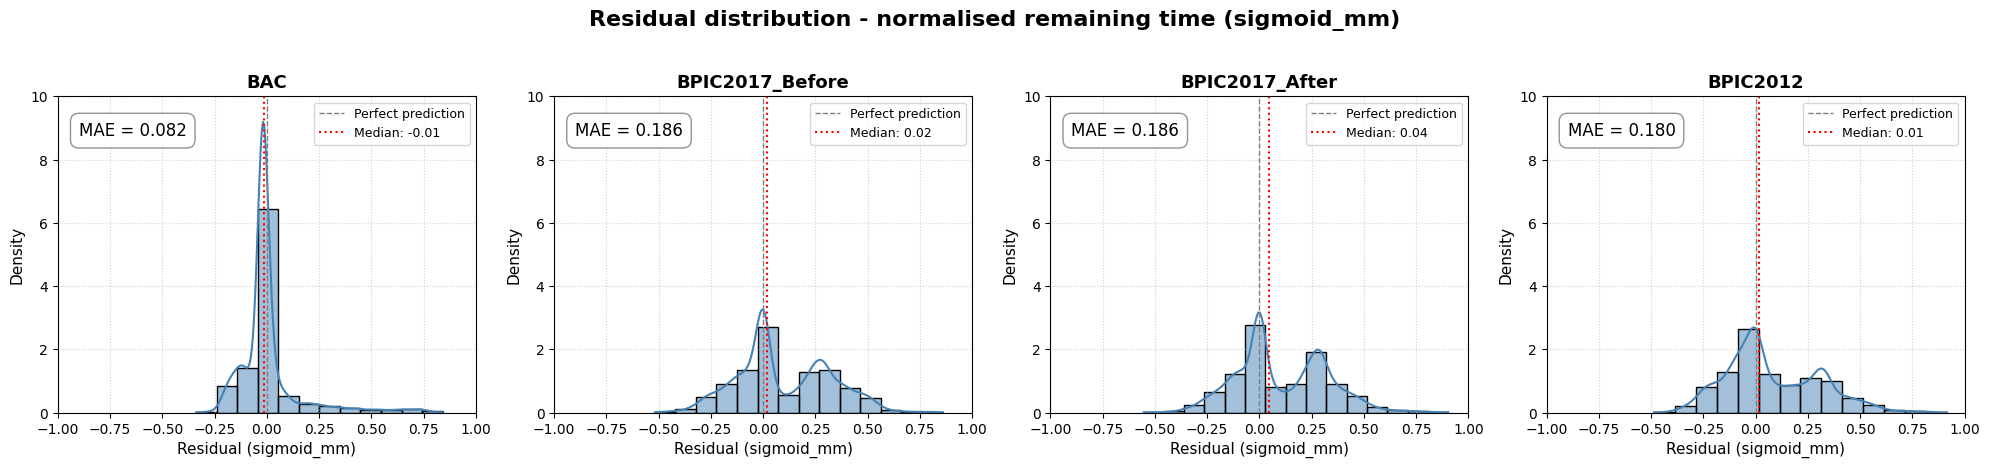

In [22]:
plot_residual_distributions(
    results_base,
    suptitle="Residual distribution - normalised remaining time (sigmoid_mm)",
    value_label="Residual (sigmoid_mm)",
)

### 1b. Predictive uncertainty of the model

The regression model is trained with `loss_function="RMSEWithUncertainty"`, so through
`UncertaintyRegressor.predict_uncertainty` every prediction carries a predictive
**standard deviation** &ndash; the aleatoric (data) noise the model expects for that
input. Only this aleatoric component is modelled.

CatBoost's raw std tends to be over-confident, so at training time a single
recalibration factor `sigma_scale` is fitted on the winning Optuna trial's held-out
slice and stored on the wrapper; `predict_uncertainty` returns the recalibrated
`sigma_scale * sigma`. This is a monotonic rescaling, so it does **not** change the
Pareto front &ndash; it only makes the interval widths honest.

Below, per dataset: the mean / median predicted std (sharpness) and the empirical
**coverage** of the `mean +/- 1 sigma` / `mean +/- 2 sigma` intervals (ideal ~ 0.68 /
0.95).

This is the same std that feeds the third Pareto objective in
`utils/recommendation_functions.py` (`predict_time_and_uncertainty`).

In [23]:
unc_results = {}
for name in DATASETS:
    ctx = load_test_context(name)
    model_sig = load_model(name, "catboost_model_sigmoid_mm.joblib")
    unc = predict_uncertainty(model_sig, ctx)
    unc_results[name] = {
        **unc,
        "residuals": ctx.y_sigmoid - unc["mean"],
        "rmse": float(np.sqrt(mean_squared_error(ctx.y_sigmoid, unc["mean"]))),
    }
    print(f"{name:<18s} mean std = {np.mean(unc['std']):.4f}  "
          f"median std = {np.median(unc['std']):.4f}")

BAC                mean std = 0.0906  median std = 0.0819
BPIC2017_Before    mean std = 0.2135  median std = 0.2741
BPIC2017_After     mean std = 0.2409  median std = 0.2922
BPIC2012           mean std = 0.1983  median std = 0.2432


In [24]:
uncertainty_table(unc_results)

,RMSE,mean_std,median_std (sharpness),coverage_1sigma,coverage_2sigma
dataset,,,,,
BAC,0.1493,0.0906,0.0819,0.823,0.952
BPIC2017_Before,0.2439,0.2135,0.2741,0.688,0.964
BPIC2017_After,0.2418,0.2409,0.2922,0.766,0.971
BPIC2012,0.2371,0.1983,0.2432,0.629,0.941


## 2. Comparison with DIEM &mdash; combined utility (weighted sum, &lambda; = 0.5)

We combine the two models of each dataset &mdash; the regressor on the remaining time
(`sigmoid_mm`) and the classifier on the completion outcome (`label`) &mdash; into a
single utility:

$$U = \lambda \,(1 - CO) + (1 - \lambda)\, RT$$

with &lambda; = 0.5. The true value uses `label` and `sigmoid_mm`; the predicted value
uses the classifier's positive-class probability and the regressor's prediction. The
resulting MAE is compared against the values reported by DIEM (`DIEM_MAE`).

In [25]:
LAMBDA = 0.5

results_combined = {}
for name in DATASETS:
    ctx = load_test_context(name)
    model_sig = load_model(name, "catboost_model_sigmoid_mm.joblib")
    model_lab = load_model(name, "catboost_model_label.joblib")

    pred_rt = predict_values(model_sig, ctx)
    pred_co = predict_positive_proba(model_lab, ctx)

    # Combined utility:  U = lambda * (1 - CO) + (1 - lambda) * RT
    y_true_comb = LAMBDA * (1.0 - ctx.y_label) + (1.0 - LAMBDA) * ctx.y_sigmoid
    y_pred_comb = LAMBDA * (1.0 - pred_co) + (1.0 - LAMBDA) * pred_rt

    results_combined[name] = make_result(y_true_comb, y_pred_comb)
    print(f"{name:<18s} combined MAE = {results_combined[name]['mae']:.4f}")

BAC                combined MAE = 0.1018
BPIC2017_Before    combined MAE = 0.2074
BPIC2017_After     combined MAE = 0.2088
BPIC2012           combined MAE = 0.2098


In [26]:
mae_table(results_combined, reference=DIEM_MAE)

,MAE,MAE_DIEM,delta
dataset,,,
BAC,0.1018,0.10,0.0018
BPIC2017_Before,0.2074,0.26,-0.0526
BPIC2017_After,0.2088,0.26,-0.0512
BPIC2012,0.2098,0.25,-0.0402


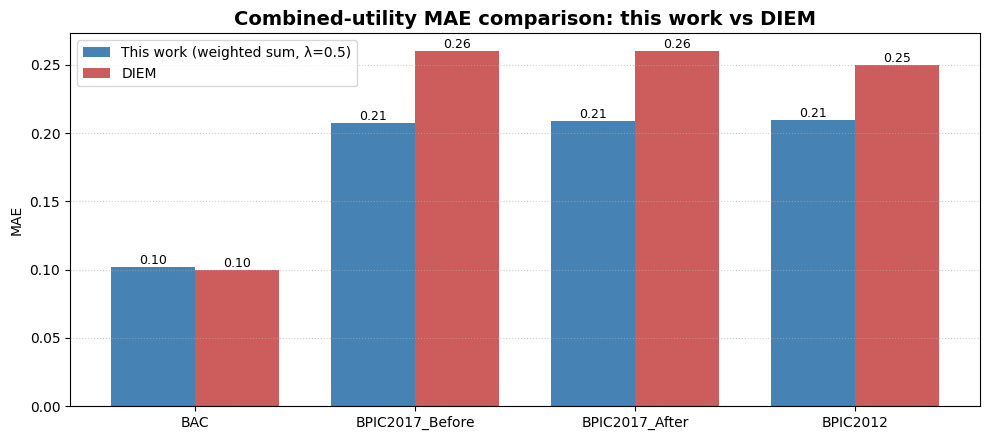

In [27]:
plot_mae_comparison(
    results_combined,
    DIEM_MAE,
    mine_label=f"This work (weighted sum, \u03bb={LAMBDA})",
    reference_label="DIEM",
    suptitle="Combined-utility MAE comparison: this work vs DIEM",
)

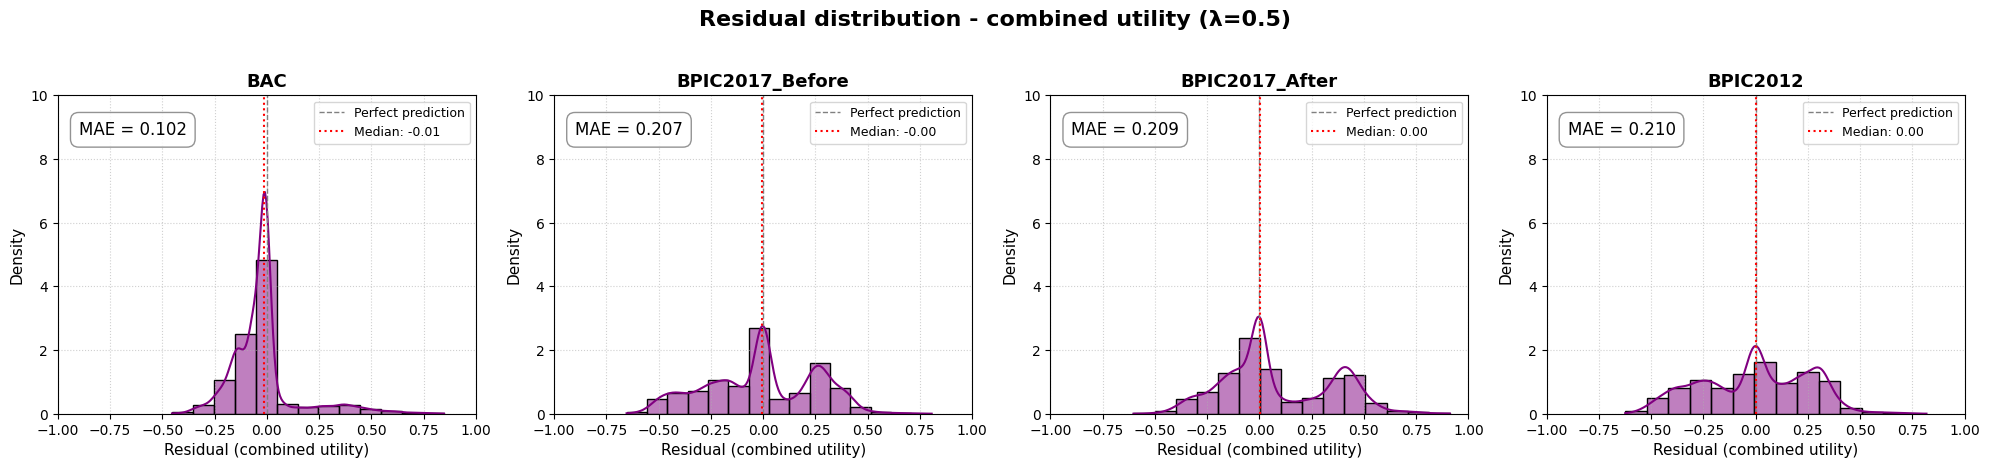

In [28]:
plot_residual_distributions(
    results_combined,
    suptitle=f"Residual distribution - combined utility (\u03bb={LAMBDA})",
    value_label="Residual (combined utility)",
    color="purple",
)

## 3. Non-normalised remaining time (real minutes)

The target `sigmoid_mm` is obtained by applying, in sequence, StandardScaler &rarr;
sigmoid &rarr; MinMaxScaler to the remaining time in seconds. To report the error in
interpretable units we re-fit the scalers on `train_data.csv`, invert the
transformation on the model prediction and convert to minutes. The true value is taken
directly from the `remaining_time` column of the test set (seconds &rarr; minutes).

In [32]:
results_minutes = {}
for name in DATASETS:
    ctx = load_test_context(name)
    model_sig = load_model(name, "catboost_model_sigmoid_mm.joblib")
    train_df = pd.read_csv(dataset_file(name, "train_data.csv"))

    scaler, mm_scaler = fit_original_scalers(train_df)

    pred_norm = predict_values(model_sig, ctx)
    y_pred_min = inverse_normalize_to_minutes(pred_norm, scaler, mm_scaler)
    y_true_min = ctx.test_df["remaining_time"].to_numpy(dtype=float) / 60.0

    results_minutes[name] = make_result(y_true_min, y_pred_min)
    print(f"{name:<18s} MAE = {results_minutes[name]['mae']:.1f} min")

BAC                MAE = 7432.5 min
BPIC2017_Before    MAE = 13567.8 min
BPIC2017_After     MAE = 13196.0 min
BPIC2012           MAE = 11687.7 min


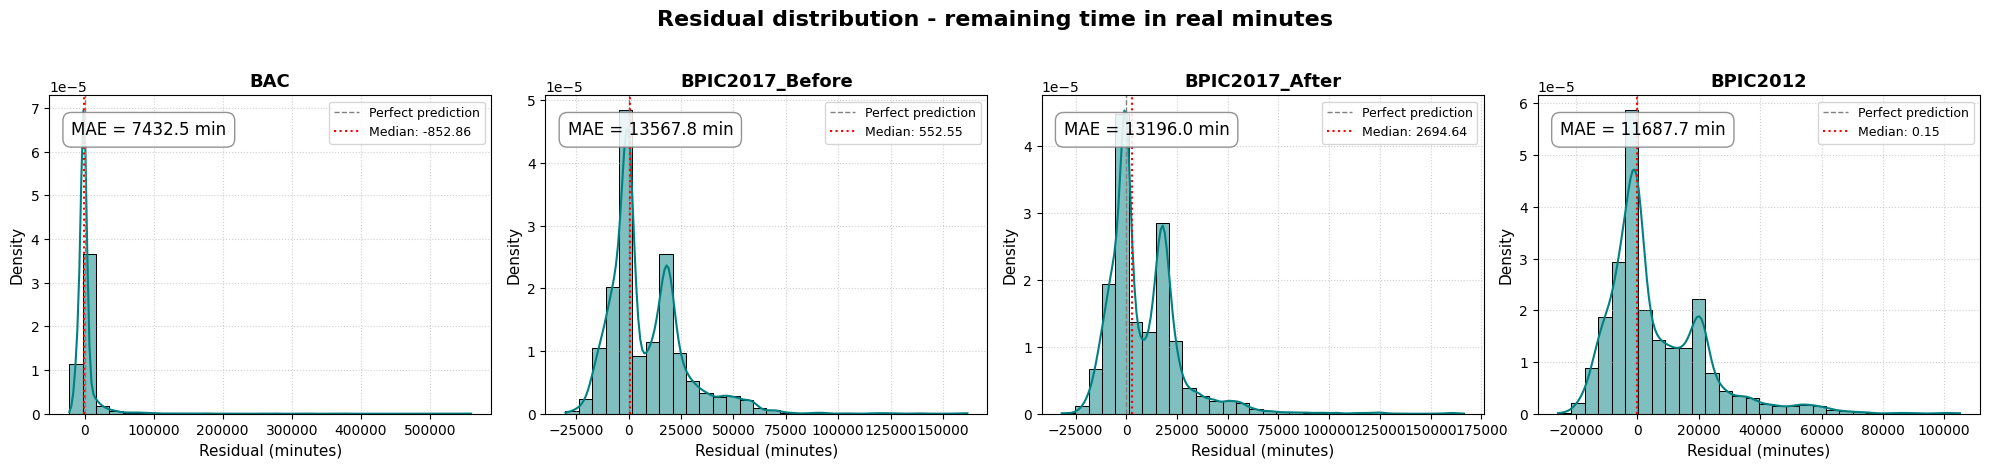

In [31]:
plot_residual_distributions(
    results_minutes,
    suptitle="Residual distribution - remaining time in real minutes",
    value_label="Residual (minutes)",
    xlim=None,
    ylim=None,
    bins=30,
    mae_fmt="{:.1f}",
    mae_suffix=" min",
    color="teal",
)